# Session 4: Convolutional Neural Networks and Filters

This notebook contains structured tasks based on Session 4 materials.

**Instructions:**
- Do NOT use a separate `.py` file. Complete all tasks directly in this notebook.
- Keep your code clear and well-commented.
- For Visulaization, please use `%matplotlib inline`
- Submit your completed notebook by uploading it to your forked repository.

### ***DO NOT UPLOAD THE DATASET TO GITHUB as it's too large***
<hr>

## Task 1: Convolutional Filters on an Image
Apply several 2D filters (Sobel X, Sobel Y, Laplacian, and Sharpen) to an image and visualize the results side by side.

**Hint:**
- Use OpenCV (`cv2.filter2D`) or NumPy to apply kernels.
- Define common kernels (Sobel, Laplacian, Sharpen).
- Use `matplotlib.pyplot` to plot the original and filtered images.

<Figure size 640x480 with 0 Axes>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-384.0..653.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5012.0..6176.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-229.0..222.0].


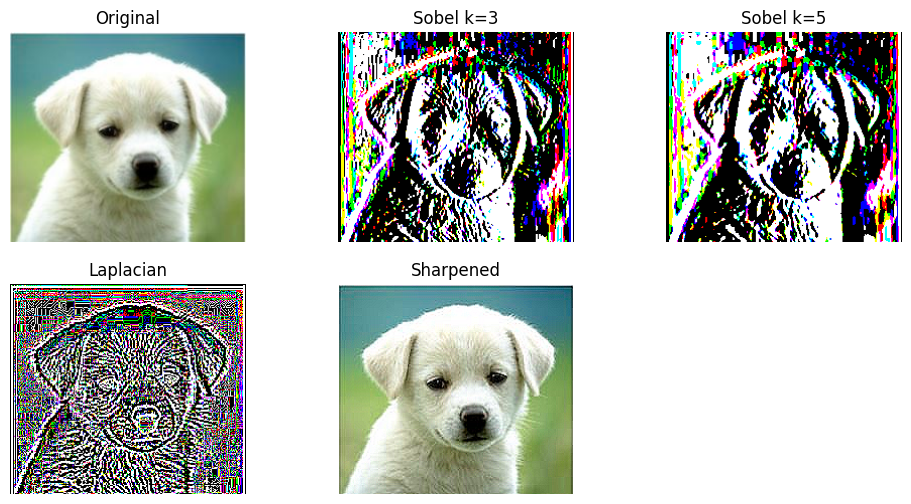

In [25]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
# TODO: Load an image (use OpenCV or matplotlib)
img=cv.imread("c:/Users/maryam/Desktop/task22/SkyXperts-Vision-Course/Session1/images/dog2.jpg",-1)
# TODO: Convert to grayscale
grey_img=cv.cvtColor(img,cv.COLOR_BGR2GRAY)
# TODO: Define Sobel, Laplacian, and Sharpen kernels
sobel3 = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=3) 
sobel5 = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=5)   
laplacian = cv.Laplacian(img, cv.CV_64F)

    
sharpen_kernel = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])
plt.tight_layout()
plt.show()
# TODO: Apply each filter to the image
sharpened = cv.filter2D(img, -1, sharpen_kernel)
# TODO: Plot results in a grid using matplotlib
titles = ["Original", "Sobel k=3", "Sobel k=5", "Laplacian", "Sharpened"]
images = [img, sobel3, sobel5, laplacian, sharpened]

plt.figure(figsize=(12, 6))
for i in range(len(images)):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i], cmap="gray")
        plt.title(titles[i])
        plt.axis("off")


## Task 2: Build a Simple CNN on FashionMNIST
Construct and train a small Convolutional Neural Network (CNN) on the FashionMNIST dataset.

**Hint:**
- Use `torchvision.datasets.FashionMNIST` for loading data.
- Define a small CNN with `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, and `nn.Linear`.
- Train for a few epochs using an optimizer (e.g., Adam) and loss function (e.g., CrossEntropyLoss).
- Print training accuracy after each epoch.

In [ ]:
# TODO: Import torch, torchvision, and related libraries
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
# TODO: Load FashionMNIST dataset with transforms
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')
# TODO: Define a simple CNN class with one conv layer and one fc layer
class BasicCNN(nn.Module):
    def __init__(self):
        super(BasicCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)  
        
        self.conv2 = nn.Conv2d(32, 64, 3)
        
        self.fc1 = nn.Linear(64 * 5 * 5, 128) 
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
       
        x = F.relu(self.conv1(x))
       
        x = F.max_pool2d(x, 2)
        
        
        x = F.relu(self.conv2(x))   
        x = F.max_pool2d(x, 2)
        x = x.view(-1, 64 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)      
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BasicCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


num_epochs = 2

for epoch in range(num_epochs):
    
    model.train()
    
    
    for images, labels in trainloader:
        
        images, labels = images.to(device), labels.to(device)
        
        
        optimizer.zero_grad()
        
        
        outputs = model(images)
        
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

## Task 3: Visualize Feature Maps
Visualize feature maps produced by the first convolutional layer of your CNN.

**Hint:**
- Take a single image from the test set.
- Pass it through the first convolutional layer (`net.conv1`).
- Convert the output to NumPy and plot several channels as images.

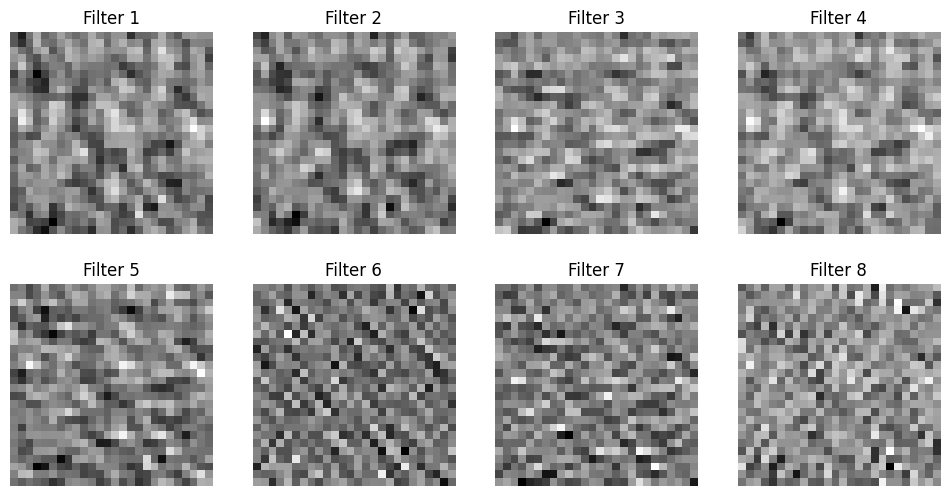

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
# TODO: Take one test image
test_img = torch.randn(1, 1, 28, 28)
# TODO: Forward pass through the first convolutional layer
with torch.no_grad():
    feature_maps = model.conv1(test_img) 
# TODO: Convert feature maps to NumPy array
    feature_maps = feature_maps.squeeze(0).cpu().numpy()
# TODO: Plot the first few feature maps in a grid
num_features_to_show = 8
plt.figure(figsize=(12, 6))
for i in range(num_features_to_show):
    plt.subplot(2, 4, i+1)
    plt.imshow(feature_maps[i], cmap='gray')
    plt.axis("off")
    plt.title(f"Filter {i+1}")
plt.show()

## Task 4: Haar Cascade Face Detection

Apply Haar Cascade classifiers for basic object detection (faces).

**Hint:**
- Use `cv2.CascadeClassifier` with a pre-trained XML file (e.g., `haarcascade_frontalface_default.xml`).
- Convert the input image to grayscale before detection.
- Use `detectMultiScale` to get bounding boxes.
- Draw rectangles on detected faces with `cv2.rectangle`.
- Visualize with Matplotlib.


✅ Image loaded
🔍 Found 1 face(s)


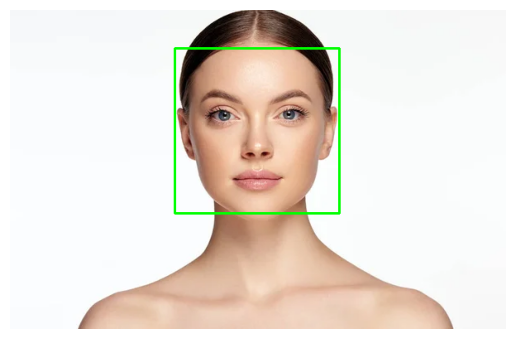

In [ ]:
import cv2 
import matplotlib.pyplot as plt
img=cv.imread("c:/Users/maryam/Desktop/task22/SkyXperts-Vision-Course/Session1/images/face.jpg",-1)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

print(f" Found {len(faces)} face(s)")

for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

